[&#8592; Previous: Loading Data](01_loading_data.ipynb)

# **ZIP to County Crosswalk**

---

Turn physician group MIPS performance, reported at the group and ZIP level, into
county level features. Groups are mapped to ZIP codes through the DAC directory,
each ZIP is apportioned to counties using the crosswalk allocation ratios, and
the result is joined to county Medicare outcomes to build the analytic tables the
modeling notebooks consume.

**Setup:** Pinned dependencies: `python -m pip install -r ../requirements.txt`

## Table of Contents

1. [Setup and load](#s1)
2. [ZIP to county crosswalk file](#s2)
3. [Clean physician group ZIP codes](#s3)
4. [Merge MIPS performance to group locations](#s4)
5. [Aggregate to the county level](#s5)
6. [County by measure table](#s6)
7. [Correlation sanity check](#s7)

---
<a id="s1"></a>

## **1. Setup and load**

Load MIPS and DAC as text so identifiers keep their leading zeros, then
standardize `org_pac_id` to a 10 digit key on both sides.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW_DATA = Path("../data/raw")  # use Path("data/raw") if running from project root

# University of Michigan palette and shared plot style
BLUE, MAIZE, GRAY = "#00274C", "#FFCB05", "#9aa0a6"
sns.set_theme(style="whitegrid", palette=[BLUE, MAIZE, GRAY])
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": BLUE,
    "axes.edgecolor": "#bbbbbb",
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.8,
})

mips = pd.read_csv(RAW_DATA / "grp_public_reporting.csv", dtype=str)
dac = pd.read_csv(RAW_DATA / "DAC_NationalDownloadableFile.csv", dtype=str)

mips.columns = mips.columns.str.strip()
dac.columns = dac.columns.str.strip()

mips["org_pac_id"] = (
    mips["org_PAC_ID"].astype("string").str.strip().str.zfill(10)
)

dac["org_pac_id"] = (
    dac["org_pac_id"].astype("string").str.strip().str.zfill(10)
)

In [2]:
print(mips["org_pac_id"].dropna().str.strip().str.len().value_counts())
print(dac["org_pac_id"].dropna().str.strip().str.len().value_counts())

org_pac_id
10    199228
Name: count, dtype: Int64
org_pac_id
10    3043125
Name: count, dtype: Int64


---
<a id="s2"></a>

## **2. ZIP to county crosswalk file**

`ZIP-COUNTY.csv` maps each ZIP to one or more counties with `tot_ratio` and `res_ratio` allocation weights.

In [3]:
zip_county = pd.read_csv(RAW_DATA / "ZIP-COUNTY.csv", dtype=str)

# Clean column names because MIPS has leading spaces
zip_county.columns = zip_county.columns.str.strip()

zip_county

,zip,geoid,res_ratio,bus_ratio,oth_ratio,tot_ratio,city,state
0,00501,36103,0.000000000,1.000000000,0.000000000,1.000000000,HOLTSVILLE,NY
1,00601,72001,0.997451580,0.994936709,0.987951807,0.997052893,ADJUNTAS,PR
2,00601,72081,0.002548420,0.005063291,0.012048193,0.002947107,ADJUNTAS,PR
3,00602,72003,0.999416278,0.998983740,1.000000000,0.999394856,AGUADA,PR
4,00602,72117,0.000583722,0.000000000,0.000000000,0.000529501,AGUADA,PR
...,...,...,...,...,...,...,...,...
54557,99926,02198,1.000000000,0.000000000,1.000000000,1.000000000,METLAKATLA,AK
54558,99927,02198,0.000000000,0.000000000,1.000000000,1.000000000,POINT BAKER,AK
54559,99928,02130,0.000000000,0.000000000,1.000000000,1.000000000,WARD COVE,AK
54560,99929,02275,1.000000000,1.000000000,1.000000000,1.000000000,WRANGELL,AK


---
<a id="s3"></a>

## **3. Clean physician group ZIP codes**

Normalize DAC ZIP codes to 5 digits and keep the valid, unique organization to ZIP pairs.

In [4]:
def clean_zip5(x):
    if pd.isna(x):
        return pd.NA
    
    x = str(x).strip()
    
    # Remove decimal artifact 
    if x.endswith(".0"):
        x = x[:-2]
    
    # Keep only digits
    digits = "".join(ch for ch in x if ch.isdigit())
    
    if len(digits) == 0:
        return pd.NA
    
    # ensure 5 digits with leading zeros if necessary
    return digits[:5].zfill(5)

dac["zip5"] = dac["ZIP Code"].apply(clean_zip5)

dac[["org_pac_id", "ZIP Code", "zip5"]].head()

,org_pac_id,ZIP Code,zip5
0,<NA>,00602,00602
1,<NA>,00602,00602
2,<NA>,00603,00603
3,<NA>,00622,00622
4,<NA>,00646,00646


In [5]:
# org_pac_id was already normalized and zero-padded in section 1; this is a
# defensive re-assert before the group filter below.
dac["org_pac_id"] = dac["org_pac_id"].astype("string").str.strip()


In [6]:
# Keep only valid, unique organization-location keys
dac_group = (
    dac.loc[
        dac["org_pac_id"].notna()
        & dac["zip5"].notna(),
        ["org_pac_id", "zip5"]
    ]
    .drop_duplicates()
    .copy()
)

print("DAC rows:", len(dac))
print("Unique organization-ZIP rows:", len(dac_group))

DAC rows: 3387942
Unique organization-ZIP rows: 227313


---
<a id="s4"></a>

## **4. Merge MIPS performance to group locations**

Slim MIPS to the columns the analysis needs, then attach group ZIP codes from DAC.

In [7]:
mips_slim = mips[
    [
        "org_pac_id",
        "Facility Name",
        "measure_cd",
        "measure_title",
        "invs_msr",
        "prf_rate",
        "patient_count",
        "star_value",
        "five_star_benchmark",
        "collection_type",
    ]
].copy()

duplicate_key = [
    "org_pac_id",
    "measure_cd",
    "collection_type",
]

print(
    mips_slim.duplicated(
        subset=duplicate_key,
        keep=False,
    ).sum()
)

0


In [8]:
merged = mips_slim.merge(
    dac_group,
    on="org_pac_id",
    how="left",
    validate="many_to_many",
)


In [9]:
missing_zip_pct=merged['zip5'].isna().sum()/len(merged)*100
print(f"{missing_zip_pct:.2f}% of rows are missing zip5")

# drop the rows we cannot place to a county, then continue
merged_no_missing_zip = merged.dropna(subset=["zip5"])

2.27% of rows are missing zip5


---
<a id="s5"></a>

## **5. Aggregate to the county level**

Apportion each ZIP to counties, weight MIPS performance by `tot_ratio`, and join to the county Medicare outcomes.

In [10]:

geo = pd.read_csv(
    RAW_DATA / "2014-2024 Original Medicare Geographic Variation Public Use File.csv",
    dtype=str
)

geo.columns = geo.columns.str.strip()

# Standardize county FIPS in geo
geo["county_fips"] = geo["BENE_GEO_CD"].astype(str).str.zfill(5)

print(geo["BENE_GEO_LVL"].value_counts(dropna=False))
print(geo["BENE_AGE_LVL"].value_counts(dropna=False))
print(geo["YEAR"].value_counts(dropna=False).sort_index())

BENE_GEO_LVL
County      35146
State        1815
National       33
Name: count, dtype: int64
BENE_AGE_LVL
All     35762
<65       616
>=65      616
Name: count, dtype: int64
YEAR
2014    3362
2015    3363
2016    3362
2017    3362
2018    3362
2019    3362
2020    3362
2021    3364
2022    3365
2023    3365
2024    3365
Name: count, dtype: int64


In [11]:
geo_county = geo[
    geo["BENE_GEO_LVL"].str.lower().eq("county")
].copy()

In [12]:

# 1. Standardize ZIP-county crosswalk keys
zip_county.columns = zip_county.columns.str.strip()

zip_county["zip5"] = zip_county["zip"].astype("string").str.zfill(5)
zip_county["county_fips"] = zip_county["geoid"].astype("string").str.zfill(5)

zip_county["tot_ratio"] = pd.to_numeric(zip_county["tot_ratio"], errors="coerce")
zip_county["res_ratio"] = pd.to_numeric(zip_county["res_ratio"], errors="coerce")

# 2. Standardize ZIP in merged MIPS/DAC file
merged_no_missing_zip = merged_no_missing_zip.copy()
merged_no_missing_zip["zip5"] = merged_no_missing_zip["zip5"].astype("string").str.zfill(5)

# 3. Merge MIPS/DAC ZIP rows to county FIPS using ZIP-county crosswalk
mips_zip_county = merged_no_missing_zip.merge(
    zip_county[["zip5", "county_fips", "tot_ratio", "res_ratio", "city", "state"]],
    on="zip5",
    how="left"
)

print("Missing county_fips after ZIP-county merge:")
print(f"{mips_zip_county['county_fips'].isna().mean() * 100:.2f}%")

# 4. Convert MIPS performance rate to numeric
mips_zip_county["prf_rate"] = pd.to_numeric(
    mips_zip_county["prf_rate"],
    errors="coerce"
)

# 5. Aggregate MIPS performance to county level
# Using tot_ratio to allocate ZIPs that span multiple counties
mips_county = (
    mips_zip_county
    .dropna(subset=["county_fips", "prf_rate", "tot_ratio"])
    .assign(weighted_prf_rate=lambda x: x["prf_rate"] * x["tot_ratio"])
    .groupby("county_fips", as_index=False)
    .agg(
        weighted_prf_rate_sum=("weighted_prf_rate", "sum"),
        weight_sum=("tot_ratio", "sum"),
        avg_prf_rate_unweighted=("prf_rate", "mean"),
        groups_count=("org_pac_id", "nunique"),
        mips_rows=("prf_rate", "size")
    )
)

mips_county["avg_prf_rate_weighted"] = (
    mips_county["weighted_prf_rate_sum"] / mips_county["weight_sum"]
)

# 6. Standardize county FIPS in geo_county
geo_county = geo_county.copy()

geo_county["county_fips"] = (
    geo_county["BENE_GEO_CD"]
    .where(geo_county["BENE_GEO_CD"].notna())
    .astype("string")
    .str.zfill(5)
)

# 7. Final county-level analytic dataset
analytic = geo_county.merge(
    mips_county,
    on="county_fips",
    how="left"
)

# 8. QA checks
print("MIPS/DAC ZIP rows:", len(merged_no_missing_zip))
print("MIPS ZIP-county rows:", len(mips_zip_county))
print("County-level MIPS rows:", len(mips_county))
print("Geo county rows:", len(geo_county))
print("Final analytic rows:", len(analytic))
print("Counties with MIPS data:", analytic["avg_prf_rate_weighted"].notna().sum())
print("Missing MIPS % in analytic:")
print(f"{analytic['avg_prf_rate_weighted'].isna().mean() * 100:.2f}%")

display(analytic.head())
display(analytic.columns)

Missing county_fips after ZIP-county merge:
0.05%


MIPS/DAC ZIP rows: 1100362
MIPS ZIP-county rows: 1526132
County-level MIPS rows: 2977
Geo county rows: 35146
Final analytic rows: 35146
Counties with MIPS data: 32426
Missing MIPS % in analytic:
7.74%


,YEAR,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL,BENES_TOTAL_CNT,BENES_WTH_PTAPTB_CNT,BENES_OM_CNT,BENES_MA_CNT,MA_PRTCPTN_RATE,...,PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65,PQI16_LWRXTRMTY_AMPUTN_AGE_65_74,PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75,county_fips,weighted_prf_rate_sum,weight_sum,avg_prf_rate_unweighted,groups_count,mips_rows,avg_prf_rate_weighted
0,2014,County,AK-Aleutians East,02013,All,168,*,117,*,*,...,NaN,NaN,NaN,02013,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,County,AK-Aleutians West,02016,All,231,136,136,0,0,...,NaN,NaN,NaN,02016,540.000,8.0,67.500000,1.0,8.0,67.500000
2,2014,County,AK-Anchorage,02020,All,33247,27755,27578,177,0.0064,...,NaN,NaN,NaN,02020,53192.533,1018.0,52.251997,49.0,1018.0,52.251997
3,2014,County,AK-Bethel,02050,All,1311,*,1059,*,*,...,NaN,NaN,NaN,02050,NaN,NaN,NaN,NaN,NaN,NaN
4,2014,County,AK-Bristol Bay,02060,All,122,104,104,0,0,...,NaN,NaN,NaN,02060,540.000,8.0,67.500000,1.0,8.0,67.500000


Index(['YEAR', 'BENE_GEO_LVL', 'BENE_GEO_DESC', 'BENE_GEO_CD', 'BENE_AGE_LVL',
       'BENES_TOTAL_CNT', 'BENES_WTH_PTAPTB_CNT', 'BENES_OM_CNT',
       'BENES_MA_CNT', 'MA_PRTCPTN_RATE',
       ...
       'PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65', 'PQI16_LWRXTRMTY_AMPUTN_AGE_65_74',
       'PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75', 'county_fips',
       'weighted_prf_rate_sum', 'weight_sum', 'avg_prf_rate_unweighted',
       'groups_count', 'mips_rows', 'avg_prf_rate_weighted'],
      dtype='object', length=253)

---
<a id="s6"></a>

## **6. County by measure table**

Repeat the county aggregation per MIPS measure to get one row per county and measure, then spot check known counties and codes.

In [13]:
mips_zip_county["prf_rate"] = pd.to_numeric(mips_zip_county["prf_rate"], errors="coerce")
mips_zip_county["tot_ratio"] = pd.to_numeric(mips_zip_county["tot_ratio"], errors="coerce")

mips_county_measure = (
    mips_zip_county
    .dropna(subset=["county_fips", "measure_cd", "prf_rate", "tot_ratio"])
    .assign(weighted_prf_rate=lambda x: x["prf_rate"] * x["tot_ratio"])
    .groupby(["county_fips", "measure_cd", "measure_title"], as_index=False)
    .agg(
        weighted_prf_rate_sum=("weighted_prf_rate", "sum"),
        weight_sum=("tot_ratio", "sum"),
        avg_prf_rate_unweighted=("prf_rate", "mean"),
        groups_count=("org_pac_id", "nunique"),
        mips_rows=("prf_rate", "size")
    )
)

mips_county_measure["avg_prf_rate_weighted"] = (
    mips_county_measure["weighted_prf_rate_sum"] / mips_county_measure["weight_sum"]
)


analytic_measure = geo_county.merge(
    mips_county_measure,
    on="county_fips",
    how="left"
)

display(analytic_measure["measure_cd"].dropna().sort_values().unique()[:50])

array(['MIPS_GRP_001_overall', 'MIPS_GRP_005_overall',
       'MIPS_GRP_006_overall', 'MIPS_GRP_007_overall',
       'MIPS_GRP_008_overall', 'MIPS_GRP_012_overall',
       'MIPS_GRP_014_overall', 'MIPS_GRP_019_overall',
       'MIPS_GRP_024_overall', 'MIPS_GRP_039_overall',
       'MIPS_GRP_047_overall', 'MIPS_GRP_048_overall',
       'MIPS_GRP_050_overall', 'MIPS_GRP_052_overall',
       'MIPS_GRP_065_overall', 'MIPS_GRP_066_overall',
       'MIPS_GRP_093_overall', 'MIPS_GRP_107_overall',
       'MIPS_GRP_112_overall', 'MIPS_GRP_113_overall',
       'MIPS_GRP_116_overall', 'MIPS_GRP_117_overall',
       'MIPS_GRP_118_overall', 'MIPS_GRP_126_overall',
       'MIPS_GRP_127_overall', 'MIPS_GRP_128_overall',
       'MIPS_GRP_130_overall', 'MIPS_GRP_134_overall',
       'MIPS_GRP_137_overall', 'MIPS_GRP_138_overall',
       'MIPS_GRP_141_overall', 'MIPS_GRP_143_overall',
       'MIPS_GRP_144_overall', 'MIPS_GRP_145_overall',
       'MIPS_GRP_147_overall', 'MIPS_GRP_155_overall',
       'MI

In [14]:
# Save the county x measure table for the modeling notebooks (03 and 04 read this)
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)
analytic_measure.to_csv(PROCESSED / "analytic_measure.csv.gz", index=False, compression="gzip")
print("wrote", PROCESSED / "analytic_measure.csv.gz", "| shape", analytic_measure.shape)

wrote ../data/processed/analytic_measure.csv.gz | shape (1611053, 255)


In [15]:
analytic_measure[
    analytic_measure["BENE_GEO_DESC"].str.contains("Washtenaw", case=False, na=False)
][["YEAR", "BENE_GEO_DESC", "county_fips"]].drop_duplicates().head(20)

,YEAR,BENE_GEO_DESC,county_fips
62655,2014,MI-Washtenaw,26161
208836,2015,MI-Washtenaw,26161
355016,2016,MI-Washtenaw,26161
501196,2017,MI-Washtenaw,26161
647376,2018,MI-Washtenaw,26161
793556,2019,MI-Washtenaw,26161
939736,2020,MI-Washtenaw,26161
1085940,2021,MI-Washtenaw,26161
1233136,2022,MI-Washtenaw,26161
1380332,2023,MI-Washtenaw,26161


In [16]:
analytic_measure[
    analytic_measure["measure_cd"].astype(str).str.contains("130", case=False, na=False)
][["measure_cd", "measure_title"]].drop_duplicates().head(20)

,measure_cd,measure_title
27,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...


In [17]:
analytic_measure[
    analytic_measure["BENE_GEO_DESC"].str.contains("Washtenaw", case=False, na=False)
    & analytic_measure["measure_cd"].astype(str).str.contains("130", case=False, na=False)
]

,YEAR,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL,BENES_TOTAL_CNT,BENES_WTH_PTAPTB_CNT,BENES_OM_CNT,BENES_MA_CNT,MA_PRTCPTN_RATE,...,PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75,county_fips,measure_cd,measure_title,weighted_prf_rate_sum,weight_sum,avg_prf_rate_unweighted,groups_count,mips_rows,avg_prf_rate_weighted
62676,2014,County,MI-Washtenaw,26161,All,52615,46137,32929,13208,0.2863,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
208857,2015,County,MI-Washtenaw,26161,All,54682,48093,33330,14763,0.307,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
355037,2016,County,MI-Washtenaw,26161,All,56551,49651,33910,15741,0.317,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
501217,2017,County,MI-Washtenaw,26161,All,58312,51262,34417,16845,0.3286,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
647397,2018,County,MI-Washtenaw,26161,All,60489,52117,33272,18845,0.3616,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
793577,2019,County,MI-Washtenaw,26161,All,62488,54286,33607,20679,0.3809,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
939757,2020,County,MI-Washtenaw,26161,All,64033,55787,31868,23919,0.4288,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
1085961,2021,County,MI-Washtenaw,26161,All,65296,56957,30978,25979,0.4561,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
1233157,2022,County,MI-Washtenaw,26161,All,66854,58590,30022,28568,0.4876,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
1380353,2023,County,MI-Washtenaw,26161,All,68205,59822,29525,30297,0.5065,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149


---
<a id="s7"></a>

## **7. Correlation sanity check**

A first look at whether county HbA1c control tracks acute hospital readmissions before the modeling notebooks.

In [18]:
county_outcome_cols = [
    # Readmissions
    "ACUTE_HOSP_READMSN_CNT",
    "ACUTE_HOSP_READMSN_PCT",

    # Emergency department
    "BENES_ER_VISITS_CNT",
    "ER_VISITS_PER_1000_BENES",
    "BENES_ER_VISITS_PCT",

    # Inpatient
    "BENES_IP_PCT",
    "IP_CVRD_STAYS_PER_1000_BENES",
    "IP_CVRD_DAYS_PER_1000_BENES",
    "IP_MDCR_PYMT_PER_USER",
    "IP_MDCR_STDZD_PYMT_PER_USER",

    # Outpatient
    "BENES_OP_PCT",
    "OP_VISITS_PER_1000_BENES",
    "OP_MDCR_PYMT_PER_USER",
    "OP_MDCR_STDZD_PYMT_PER_USER",

    # E&M
    "BENES_EM_PCT",
    "EM_EVNTS_PER_1000_BENES",
    "EM_MDCR_PYMT_PER_USER",
    "EM_MDCR_STDZD_PYMT_PER_USER",

    # SNF
    "BENES_SNF_PCT",
    "SNF_CVRD_STAYS_PER_1000_BENES",
    "SNF_CVRD_DAYS_PER_1000_BENES",
    "SNF_MDCR_PYMT_PER_USER",
    "SNF_MDCR_STDZD_PYMT_PER_USER",

    # Home health
    "BENES_HH_PCT",
    "HH_EPISODES_PER_1000_BENES",
    "HH_VISITS_PER_1000_BENES",
    "HH_MDCR_PYMT_PER_USER",
    "HH_MDCR_STDZD_PYMT_PER_USER",

    # Hospice
    "BENES_HOSPC_PCT",
    "HOSPC_CVRD_STAYS_PER_1000_BENES",
    "HOSPC_CVRD_DAYS_PER_1000_BENES",
    "HOSPC_MDCR_PYMT_PER_USER",
    "HOSPC_MDCR_STDZD_PYMT_PER_USER",

    # Procedures/tests/imaging
    "PRCDR_EVNTS_PER_1000_BENES",
    "TESTS_EVNTS_PER_1000_BENES",
    "IMGNG_EVNTS_PER_1000_BENES",
    "PRCDRS_MDCR_STDZD_PYMT_PER_USER",
    "TESTS_MDCR_STDZD_PYMT_PER_USER",
    "IMGNG_MDCR_STDZD_PYMT_PER_USER",

    # DME, ambulance, FQHC/RHC
    "DME_EVNTS_PER_1000_BENES",
    "AMBLNC_EVNTS_PER_1000_BENES",
    "FQHC_RHC_VISITS_PER_1000_BENES",
    "DME_MDCR_STDZD_PYMT_PER_USER",
    "AMBLNC_MDCR_STDZD_PYMT_PER_USER",
]

In [19]:

# HbA1c poor control measure
hba1c_measure_cd = "MIPS_GRP_001_overall"
readmission_col = "ACUTE_HOSP_READMSN_PCT"

# 1. Filter analytic_measure to HbA1c measure
hba1c = analytic_measure[
    analytic_measure["measure_cd"].eq(hba1c_measure_cd)
].copy()

# 2. Convert needed columns to numeric
hba1c["avg_prf_rate_weighted"] = pd.to_numeric(
    hba1c["avg_prf_rate_weighted"],
    errors="coerce"
)

hba1c[readmission_col] = pd.to_numeric(
    hba1c[readmission_col],
    errors="coerce"
)

# 3. Inverse measure:
# avg_prf_rate_weighted = % poor HbA1c control
# hba1c_control_score = higher is better control
hba1c["hba1c_poor_control_rate"] = hba1c["avg_prf_rate_weighted"]
hba1c["hba1c_control_score"] = 100 - hba1c["hba1c_poor_control_rate"]

# 4. Keep rows with both HbA1c and readmission data
hba1c_analysis = hba1c.dropna(
    subset=["hba1c_control_score", readmission_col]
).copy()

print("Rows available:", len(hba1c_analysis))
print("Counties available:", hba1c_analysis["county_fips"].nunique())

Rows available: 25463
Counties available: 2358


In [20]:
# 5. Correlation
corr = hba1c_analysis[
    ["hba1c_control_score", readmission_col]
].corr().iloc[0, 1]

print(f"Correlation between better HbA1c control and readmission rate: {corr:.3f}")


Correlation between better HbA1c control and readmission rate: -0.167


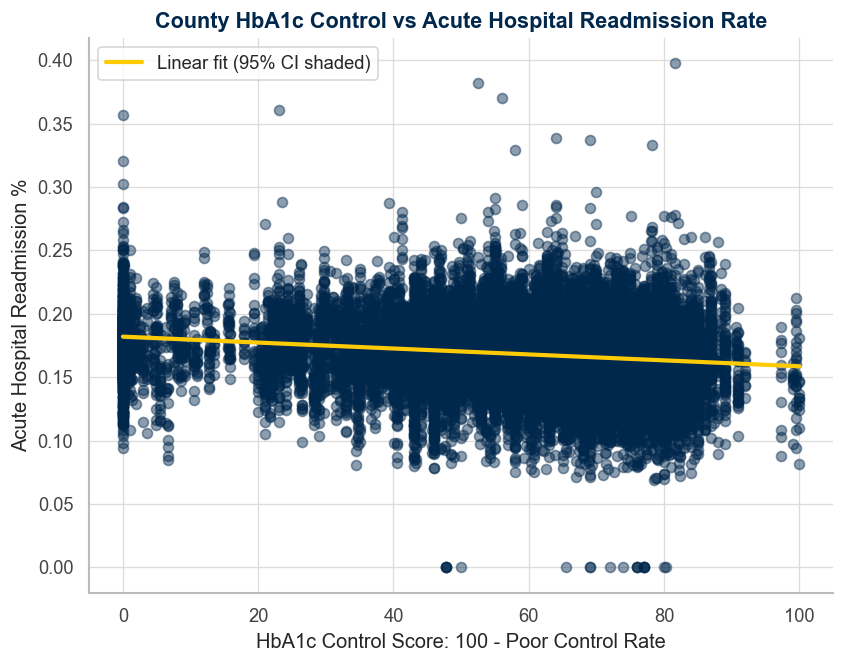

In [21]:
# 6. Scatterplot
plt.figure(figsize=(8, 6))

sns.regplot(
    data=hba1c_analysis,
    x="hba1c_control_score",
    y=readmission_col,
    scatter_kws={"alpha": 0.45, "color": BLUE, "label": "Counties"},
    line_kws={"color": MAIZE, "linewidth": 2.5, "label": "Linear fit (95% CI shaded)"},
)

plt.xlabel("HbA1c Control Score: 100 - Poor Control Rate")
plt.ylabel("Acute Hospital Readmission %")
plt.title("County HbA1c Control vs Acute Hospital Readmission Rate")
plt.legend(frameon=True)
plt.show()

---
[Next: Unsupervised Learning &#8594;](03_unsupervised_learning.ipynb)